# Module 2 — Sentiment / Emotion Classifier

**Goal:** classify the emotional tone of a customer message into
**negative / neutral / positive**, so the chatbot can route frustrated customers to a
more apologetic, priority-flagged response path.

**Dataset:** [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) —
20k English tweets labeled with 6 fine-grained emotions
(sadness, joy, love, anger, fear, surprise).

**Design decisions (documented for the assessment):**
- **Model choice — fine-tuned DistilBERT** over a from-scratch RNN. DistilBERT already
  encodes strong general-purpose language understanding (negation, sarcasm cues, context),
  which a small RNN trained only on 16k examples would struggle to learn from scratch.
  It is also ~40% smaller / faster than BERT-base, which matters since this classifier
  sits on the hot path of every customer message.
- **Label mapping (6 → 3):** we condense the fine-grained emotions into the 3 buckets the
  routing logic actually needs:
    - `negative` = sadness, anger, fear
    - `positive` = joy, love
    - `neutral`  = surprise
  Surprise is mapped to neutral rather than positive/negative because it is
  valence-ambiguous on its own (a surprising *charge on your bill* is not the same as a
  surprising *refund*) — treating it as neutral avoids injecting a wrong directional bias.
- **Domain shift caveat:** this dataset is Twitter text, not customer-support text. We
  keep a small hand-written qualitative test set (Section 8) of customer-support-style
  sentences to sanity-check that the model still behaves reasonably outside its training
  domain, and call this out explicitly as a known limitation.


In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
MODEL_NAME = "distilbert-base-uncased"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


e:\pytorch-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# 2. Load dataset (dair-ai/emotion, 'split' config gives labels 0-5)
raw = load_dataset("dair-ai/emotion", "split")
raw


e:\pytorch-gpu\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\datasets--dair-ai--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 72018.20 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
# 3. Original fine-grained label names
# 0 sadness, 1 joy, 2 love, 3 anger, 4 fear, 5 surprise
FINE_LABELS = raw["train"].features["label"].names
print(FINE_LABELS)

# Condense 6 emotions -> 3 buckets for routing (see markdown rationale above)
BUCKET_MAP = {
    "sadness": "negative",
    "anger": "negative",
    "fear": "negative",
    "joy": "positive",
    "love": "positive",
    "surprise": "neutral",
}
BUCKET_NAMES = ["negative", "neutral", "positive"]
BUCKET2ID = {name: i for i, name in enumerate(BUCKET_NAMES)}

def remap_labels(example):
    fine_name = FINE_LABELS[example["label"]]
    example["label"] = BUCKET2ID[BUCKET_MAP[fine_name]]
    return example

dataset = raw.map(remap_labels)
dataset


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


Map: 100%|██████████| 2000/2000 [00:00<00:00, 9451.37 examples/s] 


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

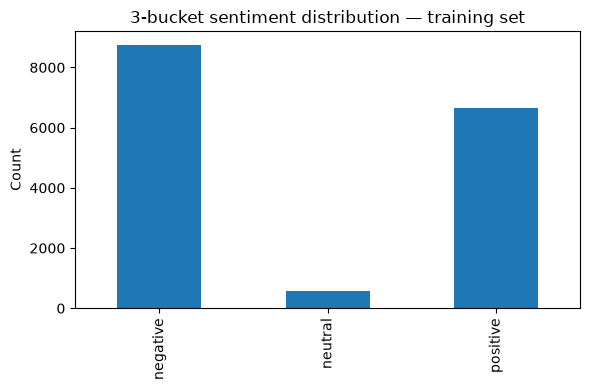

negative    0.547625
positive    0.416625
neutral     0.035750
Name: proportion, dtype: float64

In [4]:
# 4. Class balance after remapping
train_labels = pd.Series(dataset["train"]["label"]).map(
    {v: k for k, v in BUCKET2ID.items()}
)
plt.figure(figsize=(6, 4))
train_labels.value_counts().reindex(BUCKET_NAMES).plot(kind="bar")
plt.title("3-bucket sentiment distribution — training set")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
train_labels.value_counts(normalize=True)


## 4.1 Tokenization

We use DistilBERT's own WordPiece tokenizer with truncation/padding — tweets are short,
so a max length of 64 tokens comfortably covers almost all examples without wasting
compute on padding.

In [5]:
# 5. Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 64

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.remove_columns(["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized


Map: 100%|██████████| 2000/2000 [00:00<00:00, 10833.08 examples/s]


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [6]:
# 6. Load pretrained DistilBERT with a 3-class classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(BUCKET_NAMES),
    id2label={i: n for i, n in enumerate(BUCKET_NAMES)},
    label2id=BUCKET2ID,
).to(device)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13341.93it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
# 7. Metrics function used during training/eval
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }


In [9]:
# 8. Fine-tuning configuration
training_args = TrainingArguments(
    output_dir="./sentiment_ckpt",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.108172,0.078207,0.971500,0.928396
2,0.041269,0.073313,0.976000,0.935983
3,0.035079,0.078778,0.973500,0.932805


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


TrainOutput(global_step=1500, training_loss=0.10654645832379658, metrics={'train_runtime': 1024.0904, 'train_samples_per_second': 46.871, 'train_steps_per_second': 1.465, 'total_flos': 644614415862912.0, 'train_loss': 0.10654645832379658, 'epoch': 3.0})

In [10]:
# 9. Final evaluation on the held-out TEST split
test_results = trainer.predict(tokenized["test"])
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

print("Test accuracy:", accuracy_score(test_labels, test_preds))
print("Test macro-F1:", f1_score(test_labels, test_preds, average="macro"))
print()
print(classification_report(test_labels, test_preds, target_names=BUCKET_NAMES))


Test accuracy: 0.9725
Test macro-F1: 0.9057285752974051

              precision    recall  f1-score   support

    negative       0.97      0.98      0.98      1080
     neutral       0.81      0.71      0.76        66
    positive       0.98      0.98      0.98       854

    accuracy                           0.97      2000
   macro avg       0.92      0.89      0.91      2000
weighted avg       0.97      0.97      0.97      2000



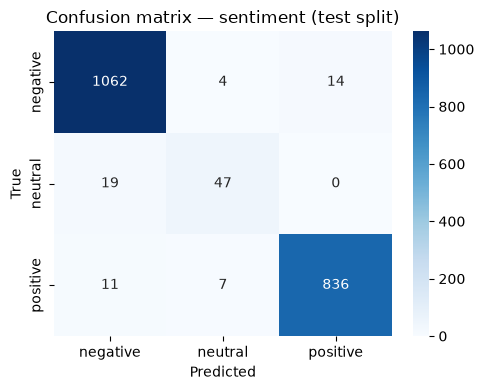

In [11]:
# 10. Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=BUCKET_NAMES, yticklabels=BUCKET_NAMES)
plt.title("Confusion matrix — sentiment (test split)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 11. Domain-shift qualitative check

The model was trained on tweets. Before trusting it on the real chatbot traffic, we
run it on a handful of hand-written **customer-support-style** sentences and eyeball
the predictions. This is exactly the kind of gap the task notes call out explicitly.

In [12]:
# 11. Save the fine-tuned model + tokenizer for deployment
trainer.save_model("sentiment_model")
tokenizer.save_pretrained("sentiment_model")
print("Saved fine-tuned model to ./sentiment_model")


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]

Saved fine-tuned model to ./sentiment_model


In [13]:
# 12. Inference helper + qualitative domain-shift spot check
from transformers import pipeline

sentiment_pipe = pipeline(
    "text-classification",
    model="sentiment_model",
    tokenizer="sentiment_model",
    device=0 if device == "cuda" else -1,
)

def predict_sentiment(text: str) -> str:
    result = sentiment_pipe(text, truncation=True, max_length=MAX_LEN)[0]
    return result["label"]

customer_support_examples = [
    "This is the third time my package has been delayed, I'm furious.",
    "Thank you so much, my refund arrived faster than expected!",
    "I'd like to know the status of my order #48213.",
    "Wait, my account was charged twice?! What is going on here.",
    "Hi, could you help me update my shipping address please.",
]

for text in customer_support_examples:
    print(f"{predict_sentiment(text):10s} <- {text}")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 679.15it/s]


negative   <- This is the third time my package has been delayed, I'm furious.
positive   <- Thank you so much, my refund arrived faster than expected!
positive   <- I'd like to know the status of my order #48213.
negative   <- Wait, my account was charged twice?! What is going on here.
positive   <- Hi, could you help me update my shipping address please.
